In [ ]:
import pandas as pd

# Import data from csv file

#Understand The data 
df = pd.read_csv('data.csv')
print(df.head())

print('Data shape')
print(f'Rows: {df.shape[0]}, Column : {df.shape[1]}')

print("Data set info")
print(df.info())

print("Summary statistic")
print(df.describe(include='all'))

print('Missing values')
print(df.isnull().sum())










   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           2          60         40      Yes           5     No
1           5          80         60       No           6    Yes
2           8          90         75      Yes           8    Yes
3           3          70         50      Yes           5     No
4           7          85         70       No           7    Yes
Data shape
Rows: 20, Column : 6
Data set info
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   StudyHours  20 non-null     int64
 1   Attendance  20 non-null     int64
 2   PastScore   20 non-null     int64
 3   Internet    20 non-null     str  
 4   SleepHours  20 non-null     int64
 5   Passed      20 non-null     str  
dtypes: int64(4), str(2)
memory usage: 1.1 KB
None
Summary statistic
        StudyHours  Attendance  PastScore Internet  SleepHours Passed
count    20.000000   2

ModuleNotFoundError: No module named 'matplotlib.pypl'

In [12]:
#Preprocessing the data of Linear Regression
import pandas as ps 
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('data.csv')

print("Missing Vakue of each column")
# print(pd.isnull().sum())

le = LabelEncoder()
df['Internet'] = le.fit_transform(df['Internet']) # yes = 1  !! no = 0
df['Passed'] = le.fit_transform(df['Passed'])  

print('After Encoding ')
print(df.head())

print("Data types after changing")
print(df.dtypes)

Missing Vakue of each column
After Encoding 
   StudyHours  Attendance  PastScore  Internet  SleepHours  Passed
0           2          60         40         1           5       0
1           5          80         60         0           6       1
2           8          90         75         1           8       1
3           3          70         50         1           5       0
4           7          85         70         0           7       1
Data types after changing
StudyHours    int64
Attendance    int64
PastScore     int64
Internet      int64
SleepHours    int64
Passed        int64
dtype: object


   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           2          60         40      Yes           5     No
1           5          80         60       No           6    Yes
2           8          90         75      Yes           8    Yes
3           3          70         50      Yes           5     No
4           7          85         70       No           7    Yes
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



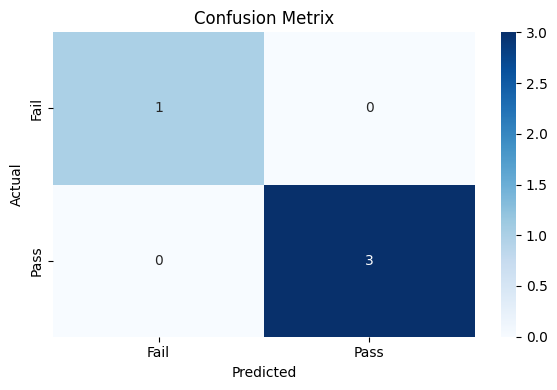

-------Predict Your Result---------
Prediction based on input : Fail


C:\Users\taufi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('data.csv')
print(df.head())

le = LabelEncoder()
df['Internet'] = le.fit_transform(df['Internet']) # yes = 1  !! no = 0
df['Passed'] = le.fit_transform(df['Passed'])  

features = ['StudyHours','Attendance','PastScore','SleepHours']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

x = df_scaled[features] # Feature
y = df_scaled['Passed'] # Target
x_train , x_test , y_train , y_test = train_test_split(x , y ,random_state=42 ,test_size=0.2  )


model = LogisticRegression()
model.fit(x_train , y_train)

y_pred = model.predict(x_test)

print("Classification Report")
print(classification_report(y_test , y_pred))

conf_matrix = confusion_matrix(y_test , y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix , annot=True , fmt='d' , cmap='Blues',
         xticklabels=['Fail','Pass'] , yticklabels=['Fail', 'Pass'] )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Metrix')
plt.tight_layout()
plt.show()

print("-------Predict Your Result---------")
try:
    study_hours = float(input("Enter your study hours:"))
    attendence= float(input("Enter your attendence:"))
    past_score = float(input("Enter your past Score:"))
    sleep_hours = float(input("Enter your sleep hours:"))

    user_input_df = pd.DataFrame([{
       'StudyHours' : study_hours,
       'Attendance' : attendence,
       'PastScore' : past_score,
       'SleepHours' : sleep_hours
    }])


    user_input_scaled = scaler.transform(user_input_df)

    predication = model.predict(user_input_scaled)[0]

    result = 'Pass' if predication == 1 else 'Fail'
    print(f'Prediction based on input : {result}')

except Exception as e:
    print("An error occour", e)



